In [1]:
import pandas as pd
pd.set_option('display.max_columns', None) 
pd.set_option('display.max_rows', None)     
pd.set_option('display.max_colwidth', None) 

数据读取成功，共 10000 行，10 列
数据前5行预览：


,ID,性别,专业,学历,毕业去向,就业行业,期望薪资,工作城市,满意度评分,是否有实习经历
0,1,男,机械工程,博士,就业,通用行业,10700.0,上海,4,否
1,2,男,临床医学,本科,考研,通用行业,13300.0,南京,3,是
2,3,男,市场营销,本科,就业,无,6400.0,无,1,是
3,4,女,土木工程,本科,就业,无,5200.0,无,4,是
4,5,NaN,电子信息,硕士,公务员,IT互联网,7700.0,武汉,3,否



数据清洗完成，有效数据量：10000 行
【1. 毕业去向分布】


,人数,占比(%)
毕业去向,,
就业,6062,60.62
考研,2450,24.50
公务员,707,7.07
出国,486,4.86
创业,205,2.05
自由职业,90,0.90


【2. 学历分布】


...

,均值,中位数,样本数
学历,,,
博士,6512.71,5700.0,480
本科,7048.19,6200.0,6991
硕士,6459.67,5700.0,2529


【5. 实习经历 对薪资&满意度影响】


,期望薪资,满意度评分,总人数
是否有实习经历,,,
否,6387.07,3.01,3582
是,7145.22,2.98,6418


【6. 平均薪资 TOP10 专业】


专业
法学       7031.20
土木工程     6991.12
汉语言文学    6925.17
环境工程     6898.24
市场营销     6889.23
金融学      6857.76
机械工程     6847.31
电子信息     6836.91
计算机      6815.42
临床医学     6625.05
Name: 期望薪资, dtype: float64

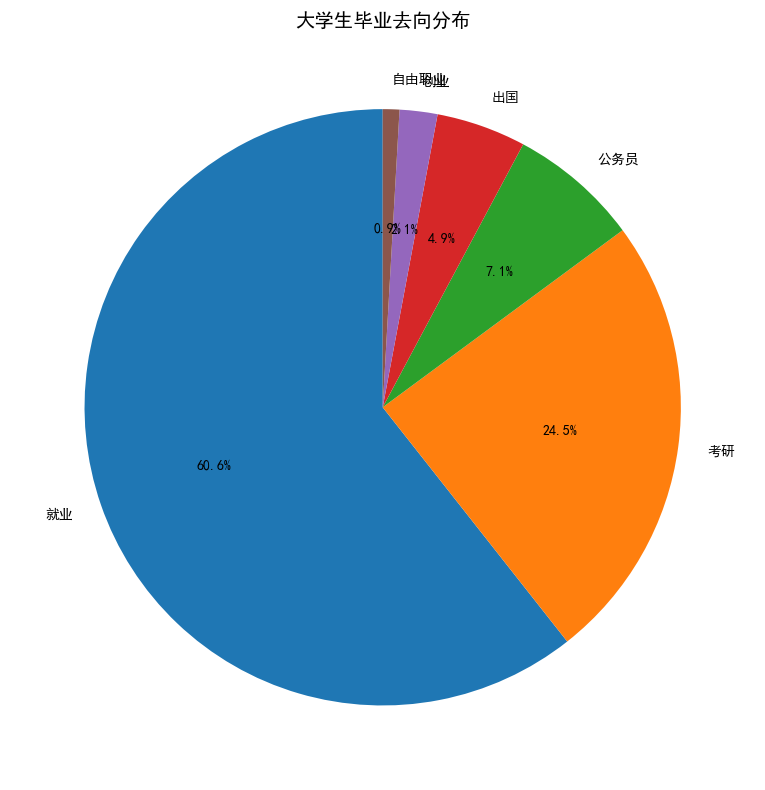

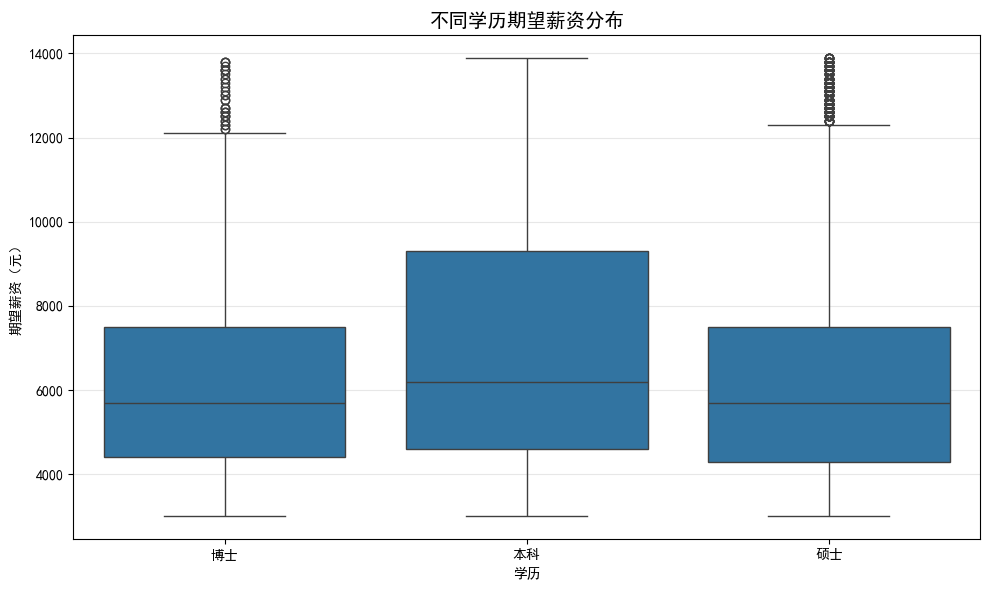

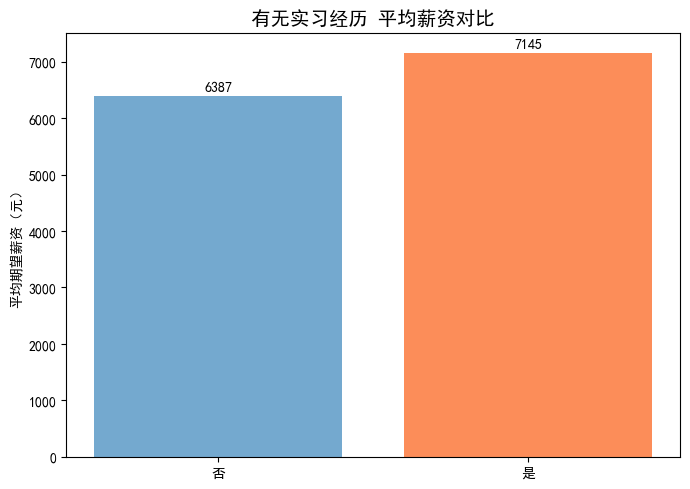

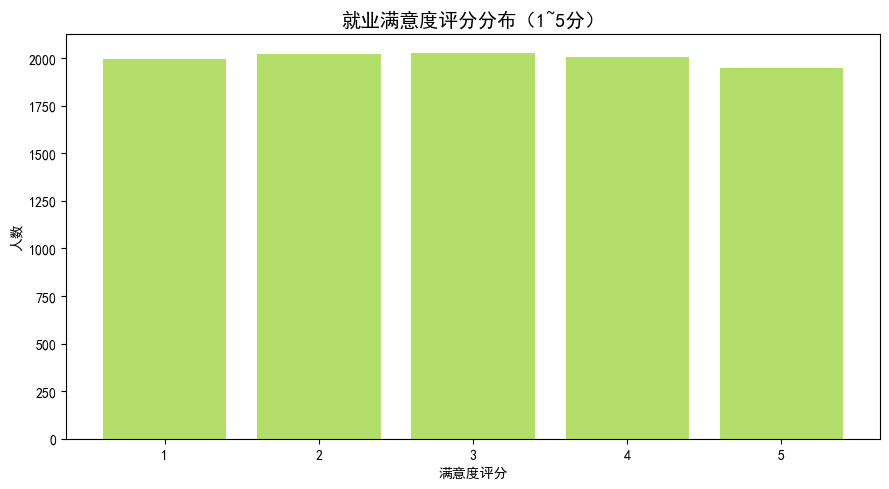

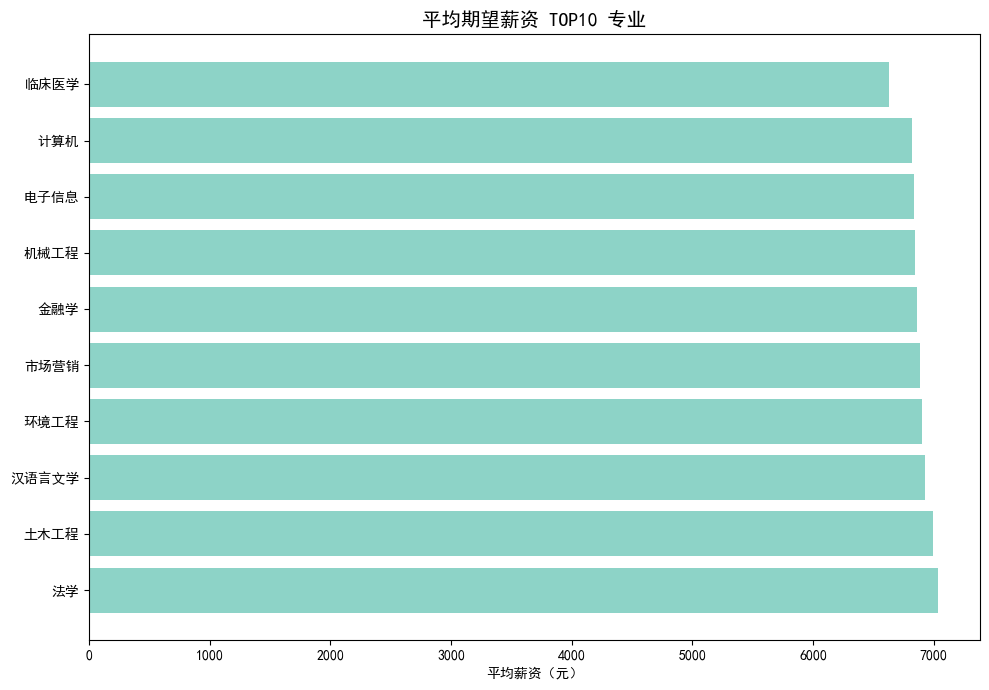


 全部分析 & 图表展示完毕，无报错！


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Jupyter 内嵌绘图设置（关键）
%matplotlib inline

# 解决中文和负号显示问题
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('大学生就业数据.csv', encoding='utf-8-sig')
print(f"数据读取成功，共 {df.shape[0]} 行，{df.shape[1]} 列")
print("数据前5行预览：")
display(df.head())

# 缺失值填充
df['性别'] = df['性别'].fillna('未知')
df['期望薪资'] = df['期望薪资'].fillna(df['期望薪资'].median())
df['是否有实习经历'] = df['是否有实习经历'].fillna('否')

# 统一异常标签
df['工作城市'] = df['工作城市'].replace('无', '未填写')
df['就业行业'] = df['就业行业'].replace('无', '未填写')

# 去重
df = df.drop_duplicates()
print(f"\n数据清洗完成，有效数据量：{df.shape[0]} 行")

print("=" * 60)
print("【1. 毕业去向分布】")
grad_dest = df['毕业去向'].value_counts()
grad_pct = df['毕业去向'].value_counts(normalize=True).round(4) * 100
dest_result = pd.DataFrame({
    "人数": grad_dest,
    "占比(%)": grad_pct
})
display(dest_result)

print("=" * 60)
print("【2. 学历分布】")
edu_count = df['学历'].value_counts()
edu_pct = df['学历'].value_counts(normalize=True).round(4) * 100
edu_result = pd.DataFrame({
    "人数": edu_count,
    "占比(%)": edu_pct
})
display(edu_result)

print("=" * 60)
print("【3. 期望薪资整体统计】")
salary_desc = df['期望薪资'].describe().round(2)
display(salary_desc)

print("=" * 60)
print("【4. 不同学历 期望薪资对比】")
edu_salary = df.groupby('学历')['期望薪资'].agg(['mean', 'median', 'count']).round(2)
edu_salary.columns = ['均值', '中位数', '样本数']
display(edu_salary)

print("=" * 60)
print("【5. 实习经历 对薪资&满意度影响】")
intern_analy = df.groupby('是否有实习经历').agg({
    "期望薪资": "mean",
    "满意度评分": "mean",
    "ID": "count"
}).round(2)
intern_analy.rename(columns={"ID":"总人数"}, inplace=True)
display(intern_analy)

print("=" * 60)
print("【6. 平均薪资 TOP10 专业】")
major_salary = df.groupby('专业')['期望薪资'].mean().sort_values(ascending=False).head(10).round(2)
display(major_salary)

# 1. 毕业去向饼图
plt.figure(figsize=(8, 8))
plt.pie(grad_dest.values, labels=grad_dest.index, autopct='%1.1f%%', startangle=90)
plt.title("大学生毕业去向分布", fontsize=14)
plt.tight_layout()
plt.show()

# 2. 学历-薪资箱线图
plt.figure(figsize=(10, 6))
sns.boxplot(x="学历", y="期望薪资", data=df)
plt.title("不同学历期望薪资分布", fontsize=14)
plt.xlabel("学历")
plt.ylabel("期望薪资（元）")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 3. 实习经历 vs 平均薪资
plt.figure(figsize=(7, 5))
intern_sal = df.groupby("是否有实习经历")["期望薪资"].mean()
plt.bar(intern_sal.index, intern_sal.values, color=["#74a9cf", "#fc8d59"])
plt.title("有无实习经历 平均薪资对比", fontsize=14)
plt.ylabel("平均期望薪资（元）")
for idx, val in enumerate(intern_sal.values):
    plt.text(idx, val + 100, f"{int(val)}", ha="center")
plt.tight_layout()
plt.show()

# 4. 满意度分布柱状图
plt.figure(figsize=(9, 5))
satisfy = df["满意度评分"].value_counts().sort_index()
plt.bar(satisfy.index.astype(str), satisfy.values, color="#b3de69")
plt.title("就业满意度评分分布（1~5分）", fontsize=14)
plt.xlabel("满意度评分")
plt.ylabel("人数")
plt.tight_layout()
plt.show()

# 5. 薪资TOP10专业 横向柱状图（修复了变量名错误，使用前面定义的major_salary）
plt.figure(figsize=(10, 7))
plt.barh(major_salary.index, major_salary.values, color="#8dd3c7")
plt.title("平均期望薪资 TOP10 专业", fontsize=14)
plt.xlabel("平均薪资（元）")
plt.tight_layout()
plt.show()

print("\n 全部分析 & 图表展示完毕，无报错！")